In [15]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, roc_curve, auc

import warnings
warnings.filterwarnings("ignore")

In [16]:

data = load_breast_cancer()

X = data.data
y = data.target

feature_names = data.feature_names

print("Total samples:", X.shape[0])
print("Total features:", X.shape[1])
print("Classes:", data.target_names)

Total samples: 569
Total features: 30
Classes: ['malignant' 'benign']


In [20]:

unique, counts = np.unique(y, return_counts=True)

for label, count in zip(data.target_names, counts):
    print(label, ":", count)

malignant : 212
benign : 357


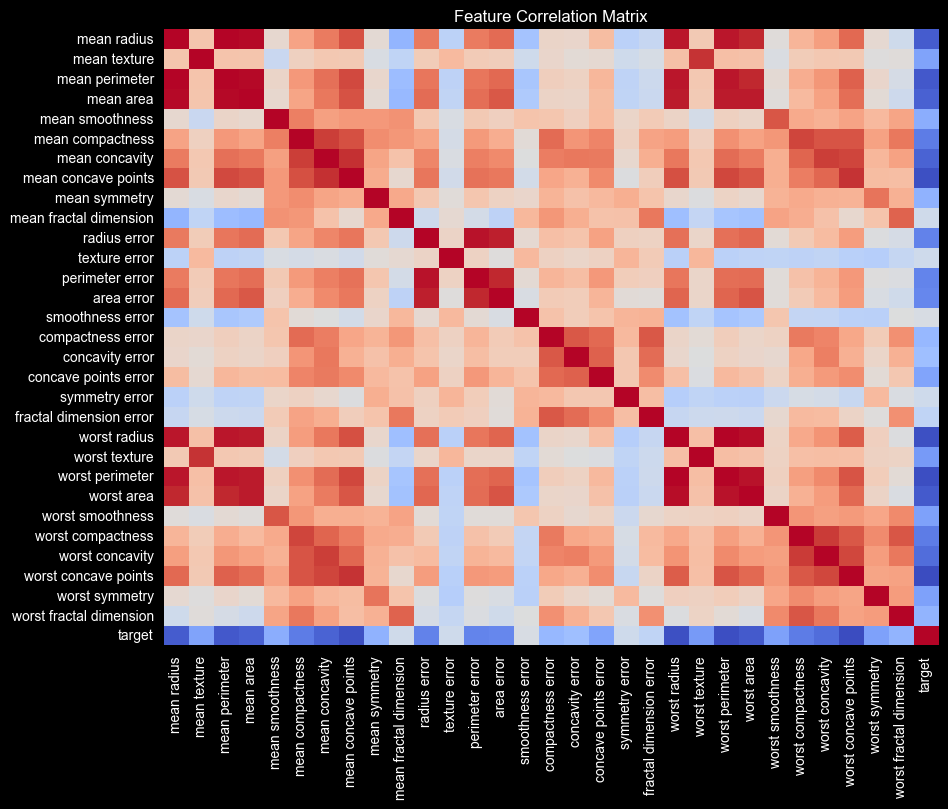

In [19]:

df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm", cbar=False)
plt.title("Feature Correlation Matrix")
plt.show()

In [21]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 455
Testing samples: 114


In [22]:

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9122807017543859


In [23]:

dt_params = [
    ("gini", 3),
    ("gini", 5),
    ("entropy", 3),
    ("entropy", 5)
]

In [24]:

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_results = []

for criterion, depth in dt_params:

    model = DecisionTreeClassifier(
        criterion=criterion,
        max_depth=depth,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    )

    acc_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')
    f1_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='f1')

    dt_results.append([
        criterion,
        depth,
        acc_scores.mean(),
        f1_scores.mean()
    ])

dt_results_df = pd.DataFrame(
    dt_results,
    columns=["Criterion", "Max Depth", "Avg CV Accuracy", "Avg CV F1"]
)

dt_results_df

,Criterion,Max Depth,Avg CV Accuracy,Avg CV F1
0,gini,3,0.925275,0.939951
1,gini,5,0.923077,0.937250
2,entropy,3,0.934066,0.947973
3,entropy,5,0.929670,0.943867


RANDOM FOREST

In [25]:
rf_params = [
    (50, 3, "sqrt"),
    (100, 5, "sqrt"),
    (100, None, "log2"),
    (200, None, "sqrt")
]

In [26]:
rf_results = []

for n_estimators, depth, max_feat in rf_params:

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=depth,
        max_features=max_feat,
        bootstrap=True,
        random_state=42
    )

    acc_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')
    f1_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='f1')

    rf_results.append([
        n_estimators,
        depth,
        max_feat,
        acc_scores.mean(),
        f1_scores.mean()
    ])

rf_results_df = pd.DataFrame(
    rf_results,
    columns=["n_estimators", "Max Depth", "Max Features", "Avg CV Accuracy", "Avg CV F1"]
)

rf_results_df

,n_estimators,Max Depth,Max Features,Avg CV Accuracy,Avg CV F1
0,50,3.0,sqrt,0.951648,0.961292
1,100,5.0,sqrt,0.960440,0.968530
2,100,NaN,log2,0.964835,0.971801
3,200,NaN,sqrt,0.962637,0.970027


In [27]:

best_dt = dt_results_df.sort_values("Avg CV Accuracy", ascending=False).iloc[0]
best_rf = rf_results_df.sort_values("Avg CV Accuracy", ascending=False).iloc[0]

print("Best Decision Tree Config:")
print(best_dt)

print("\nBest Random Forest Config:")
print(best_rf)

Best Decision Tree Config:
Criterion           entropy
Max Depth                 3
Avg CV Accuracy    0.934066
Avg CV F1          0.947973
Name: 2, dtype: object

Best Random Forest Config:
n_estimators            100
Max Depth               NaN
Max Features           log2
Avg CV Accuracy    0.964835
Avg CV F1          0.971801
Name: 2, dtype: object


In [28]:
final_dt = DecisionTreeClassifier(
    criterion=best_dt["Criterion"],
    max_depth=int(best_dt["Max Depth"]),
    random_state=42
)

final_dt.fit(X_train, y_train)
y_pred_dt = final_dt.predict(X_test)

In [29]:
final_rf = RandomForestClassifier(
    n_estimators=int(best_rf["n_estimators"]),
    max_depth=None if pd.isna(best_rf["Max Depth"]) else int(best_rf["Max Depth"]),
    max_features=best_rf["Max Features"],
    bootstrap=True,
    random_state=42
)

final_rf.fit(X_train, y_train)
y_pred_rf = final_rf.predict(X_test)

In [30]:
def evaluate(name, y_true, y_pred):
    print("\n", name)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))

evaluate("Decision Tree", y_test, y_pred_dt)
evaluate("Random Forest", y_test, y_pred_rf)


 Decision Tree
Accuracy: 0.9473684210526315
Precision: 0.9459459459459459
Recall: 0.9722222222222222
F1 Score: 0.958904109589041

 Random Forest
Accuracy: 0.956140350877193
Precision: 0.958904109589041
Recall: 0.9722222222222222
F1 Score: 0.9655172413793104


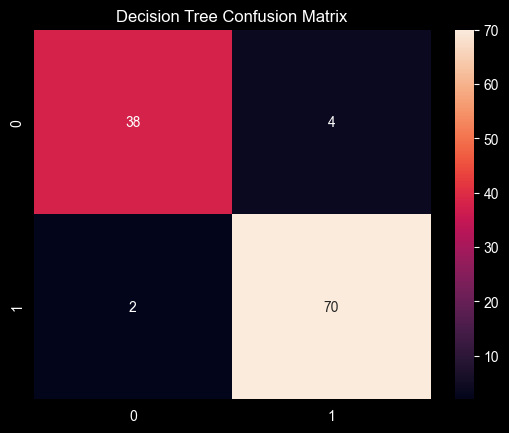

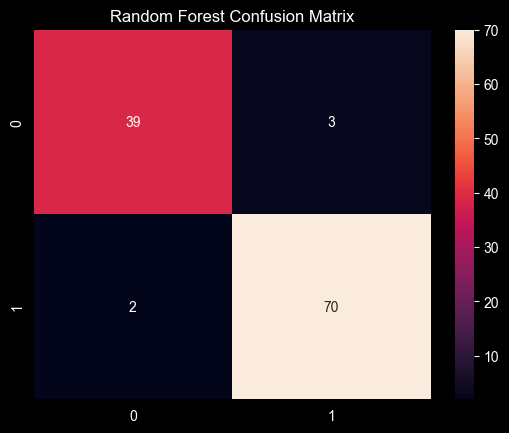

In [31]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure()
sns.heatmap(cm_dt, annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.show()

plt.figure()
sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()

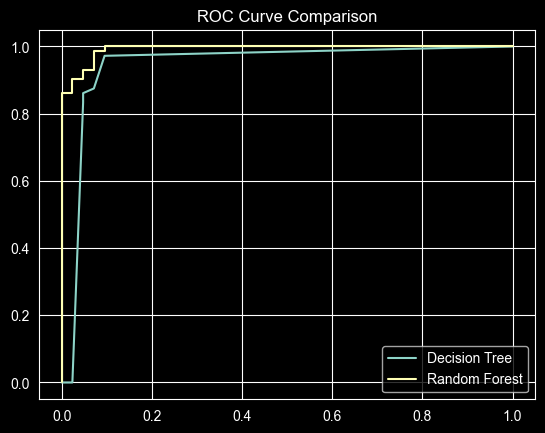

In [32]:
y_prob_dt = final_dt.predict_proba(X_test)[:,1]
y_prob_rf = final_rf.predict_proba(X_test)[:,1]

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure()
plt.plot(fpr_dt, tpr_dt, label="Decision Tree")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.legend()
plt.title("ROC Curve Comparison")
plt.show()